# Workshop 04 — Reading the Posterior

[workshop_03](workshop_03_first_mmm.ipynb) ended with a bar chart: one number
per channel. But the model didn't give you a bar chart — it gave you **a
thousand complete, internally-consistent versions of reality**, each one a full
set of parameter values that could plausibly have produced your data. The bar
chart was just one way of squashing them.

Reading the posterior means learning to use *all* of them. That's this
notebook:

1. **The posterior is a table of worlds** — what a *draw* actually is.
2. **Summaries done right** — mean vs median, and **HDI** vs equal-tailed
   intervals (they differ exactly where it matters).
3. **The forest plot** — the whole posterior at a glance, channel by channel.
4. **Joint structure** — the correlations that point estimates hide, and why
   you can never mix-and-match "best" values.
5. **Did the data actually teach us anything?** — prior→posterior learning
   with the framework's real diagnostic.
6. **The posterior predictive check** — does the model reproduce your data?
7. **Decomposition with uncertainty** — where the KPI came from, week by week,
   with honest error bars (and, because this world is synthetic, the *true*
   answer drawn on top).

Same world, same fit as workshop_03 — the synthetic **"clean" world** from
`tests/synth/dgp.py`, where we know the exact causal truth, so every reading
skill we practice can be checked against the answer key.

> Where you are in the series: [00](workshop_00_thinking_in_distributions.ipynb) Bayes' rule ·
> [01](workshop_01_priors.ipynb) priors · [02](workshop_02_sampling.ipynb) MCMC ·
> [03](workshop_03_first_mmm.ipynb) first fit · **04 reading the posterior
> (you are here)** · [05](workshop_05_from_draws_to_decisions.ipynb) from draws
> to decisions.

In [1]:
import sys, pathlib, warnings, logging, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
# pymc emits sampler warnings at ERROR level -> CRITICAL to keep outputs clean
for _n in ("pymc", "numpyro", "jax", "arviz", "pytensor"):
    logging.getLogger(_n).setLevel(logging.CRITICAL)
try:  # the validation suite logs via loguru, which bypasses stdlib logging
    from loguru import logger as _loguru
    _loguru.disable("mmm_framework")
except ImportError:
    pass
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # repo root (run from nbs/)

import contextlib, os
@contextlib.contextmanager
def quiet():
    "Hide the samplers' progress bars / chatter; our own prints stay visible."
    with open(os.devnull, "w") as _dn, contextlib.redirect_stdout(_dn), \
            contextlib.redirect_stderr(_dn):
        yield

import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "notebook_connected"

from tests.synth import dgp  # the known-truth synthetic worlds from workshop_03

plt.rcParams.update({
    "figure.figsize": (9, 4), "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110,
})
INK, ACCENT, SKY, BERRY, LEAF, AMBER, MUTED = (
    "#2b2118", "#b5651d", "#3b6ea5", "#a63a50", "#3f7d5e", "#d98a2b", "#8a8079")
PAL = {"TV": ACCENT, "Search": SKY, "Social": BERRY, "Display": LEAF}
print("setup ok — plotly renderer:", pio.renderers.default)
assert pio.renderers.default == "notebook_connected"

setup ok — plotly renderer: notebook_connected


## 1 — The fit we're going to read

Exactly the model and world from workshop_03: the **clean world** (four media
channels — TV, Search, Social, Display — driving weekly sales, with carryover,
diminishing returns, trend, seasonality, and one control), fit with NUTS via
numpyro at 500 draws × 2 chains. One fit; everything else in this notebook is
*reading*, not refitting.

Because the world is synthetic, `sc.true_contribution` holds each channel's
**true causal contribution** — the sales that would vanish if that channel's
spend were zeroed out. That's our answer key.

In [2]:
from mmm_framework.config import InferenceMethod, ModelConfig
from mmm_framework.model import BayesianMMM, TrendConfig, TrendType

# Importing pymc installs its own log handler; re-quiet and stop propagation.
for _n in ("pymc", "pymc.sampling", "pymc.stats.convergence",
           "numpyro", "jax", "arviz", "pytensor"):
    _lg = logging.getLogger(_n); _lg.setLevel(logging.CRITICAL); _lg.propagate = False

sc = dgp.build("clean")
cfg = ModelConfig(
    inference_method=InferenceMethod.BAYESIAN_NUMPYRO,
    n_draws=500, n_tune=500, n_chains=2,
    use_parametric_adstock=True, optim_seed=0,
)
mmm = BayesianMMM(sc.panel(), cfg, TrendConfig(type=TrendType.LINEAR))
t0 = time.perf_counter()
with quiet():
    fit = mmm.fit(random_seed=0)
print(f"fit in {time.perf_counter() - t0:.0f}s   "
      f"r-hat max={fit.diagnostics['rhat_max']:.3f}  "
      f"divergences={fit.diagnostics['divergences']}  "
      f"min bulk ESS={fit.diagnostics['ess_bulk_min']:.0f}")
print("channels:", sc.channels, "  weeks:", len(sc.weeks))
print("true contributions (the answer key):")
print(sc.true_contribution.round().to_string())

# CLAIM: the workshop_02 gates are green — this posterior is safe to read.
assert fit.diagnostics["rhat_max"] < 1.05, "chains disagree — do not read further"
assert fit.diagnostics["divergences"] == 0
assert fit.diagnostics["ess_bulk_min"] > 100
print("✓ convergence gates pass — the posterior below is trustworthy as a computation")

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

fit in 17s   r-hat max=1.009  divergences=0  min bulk ESS=355
channels: ['TV', 'Search', 'Social', 'Display']   weeks: 156
true contributions (the answer key):
TV         5668.0
Search     4531.0
Social     4017.0
Display    2958.0
✓ convergence gates pass — the posterior below is trustworthy as a computation


## 2 — The posterior is a TABLE of worlds

The fit's output lives in an arviz `InferenceData` object (at `fit.trace`, or
`mmm._trace`). Inside its `posterior` group is, conceptually, a big table:

- each **column** is a parameter of the model (a channel's effect size
  `beta_TV`, its carryover rate `adstock_alpha_TV`, its diminishing-returns
  curvature `sat_lam_TV`, the trend slope, ...);
- each **row** is one **draw** (also called a **sample**) — *one complete,
  self-consistent setting of every parameter at once*, kept by the MCMC
  sampler from workshop_02 because it explains the data plausibly.

Two chains × 500 draws = 1,000 rows. Let's actually look at it.

In [3]:
idata = mmm._trace          # the arviz InferenceData (same object as fit.trace)
post = idata.posterior
print("groups in the InferenceData:", list(idata.groups()))
print("posterior dimensions:", dict(post.sizes))
scalar_params = sorted(v for v in post.data_vars
                       if set(post[v].dims) == {"chain", "draw"})
print(f"{len(scalar_params)} scalar parameters:")
print(" ", scalar_params)

# CLAIM: the posterior really is chains x draws, with named per-channel params.
assert post.sizes["chain"] == 2 and post.sizes["draw"] == 500
for c in sc.channels:
    for stem in ("beta_", "adstock_alpha_", "sat_lam_"):
        assert f"{stem}{c}" in post.data_vars, f"missing {stem}{c}"
print("✓ posterior = 2 chains × 500 draws, one named parameter set per channel")

groups in the InferenceData: ['posterior', 'sample_stats', 'prior', 'prior_predictive', 'observed_data', 'constant_data']
posterior dimensions: {'chain': 2, 'draw': 500, 'yearly_fourier': 4, 'beta_controls_dim_0': 1, 'obs': 156, 'trend_component_dim_0': 156, 'seasonality_component_dim_0': 156, 'seasonality_by_period_dim_0': 156, 'channel': 4, 'media_total_dim_0': 156, 'control': 1}
15 scalar parameters:
  ['adstock_alpha_Display', 'adstock_alpha_Search', 'adstock_alpha_Social', 'adstock_alpha_TV', 'beta_Display', 'beta_Search', 'beta_Social', 'beta_TV', 'intercept', 'sat_lam_Display', 'sat_lam_Search', 'sat_lam_Social', 'sat_lam_TV', 'sigma', 'trend_slope']
✓ posterior = 2 chains × 500 draws, one named parameter set per channel


In [4]:
# The literal table: a few named columns, first rows. Each ROW is one world.
peek_cols = ["beta_TV", "adstock_alpha_TV", "sat_lam_TV", "beta_Search", "trend_slope"]
worlds = post[peek_cols].to_dataframe().reset_index()
display(worlds.head(8).round(3))
print(f"... and {len(worlds) - 8:,} more rows like these")

# CLAIM: 1,000 complete worlds; no missing entries — every draw sets EVERY parameter.
assert len(worlds) == 1000
assert worlds[peek_cols].notna().all().all()
print("✓ 1,000 rows × every parameter — the posterior is this table")

,chain,draw,beta_TV,adstock_alpha_TV,sat_lam_TV,beta_Search,trend_slope
0,0,0,1.824,0.425,2.436,1.287,1.045
1,0,1,1.589,0.553,3.363,1.451,1.048
2,0,2,1.935,0.408,1.846,1.156,1.049
3,0,3,1.599,0.519,2.733,1.031,1.031
4,0,4,2.150,0.525,2.230,1.569,1.047
5,0,5,1.880,0.551,2.836,1.045,1.059
6,0,6,3.098,0.536,1.267,1.467,1.173
7,0,7,2.426,0.553,1.947,1.206,0.983


... and 992 more rows like these
✓ 1,000 rows × every parameter — the posterior is this table


Read one row across: *"maybe TV's effect is this big, with this much carryover
and this much curvature, while Search's effect is that big and the trend climbs
at this rate."* That entire sentence — all parameters together — is one draw.

This is the single most important mental model in the series:

> **A draw is a whole world, not a grab-bag of separate numbers.** Parameters
> within a row were accepted *together*, so they are mutually consistent: rows
> where TV's curve bends harder tend to be rows where TV's effect size is
> larger to compensate (we'll see exactly that in section 5). The rows agree
> with the data; they disagree with *each other* — and the spread of their
> disagreement **is** your uncertainty.

Everything else in this notebook is just different ways of looking at this
table: one column at a time (a **marginal** — the distribution of a single
parameter ignoring the others), two columns at a time (a **joint** view), or
whole-row computations (next workshop).

## 3 — Summaries done right: mean, median, and the HDI

A thousand numbers per parameter is too many for a slide, so we summarize. Two
decisions hide inside every summary, and both have a right answer:

**Center.** The **mean** (average of the draws) and the **median** (the middle
draw) agree when the marginal is symmetric. When it's *skewed* — a long tail on
one side, common for effect sizes that must be positive — the mean gets dragged
toward the tail. Neither is wrong; they answer different questions (the mean
is what you'd earn on average across worlds; the median is the 50/50 point).
Just know which one your table reports.

**Interval.** Two ways to build a "90% range":

- the **equal-tailed interval (ETI)** — chop 5% off each end (the 5th to 95th
  percentile). Simple, but on a skewed marginal it can *exclude* values more
  plausible than ones it includes.
- the **HDI** (**highest-density interval**) — the *narrowest* range holding
  90% of the draws: every value inside is more plausible than every value
  outside. This is the framework's default, and the one to report.

Our posterior has genuinely skewed marginals, so we can see the difference
live instead of taking it on faith. The cell below finds the most-skewed
effect-size or curvature parameter and draws both intervals on it.

In [5]:
import arviz as az
from scipy import stats as sps
from scipy.stats import gaussian_kde

# Find the most-skewed beta_* / sat_lam_* marginal — programmatically, so the
# choice (and the rest of this section) doesn't depend on hand-picked numbers.
cands = [v for v in scalar_params if v.startswith(("beta_", "sat_lam_"))]
skews = pd.Series({v: float(sps.skew(post[v].values.ravel())) for v in cands})
skew_param = skews.abs().idxmax()
s = post[skew_param].values.ravel()
print(f"most-skewed marginal: {skew_param}  (skewness {skews[skew_param]:+.2f})")
print(skews.sort_values(ascending=False).round(2).to_string())

mean_, med_ = float(s.mean()), float(np.median(s))
hdi = az.hdi(s, hdi_prob=0.90)
eti = np.percentile(s, [5, 95])
print(f"mean={mean_:.3f}  median={med_:.3f}")
print(f"90% HDI=({hdi[0]:.3f}, {hdi[1]:.3f})  width {hdi[1]-hdi[0]:.3f}")
print(f"90% ETI=({eti[0]:.3f}, {eti[1]:.3f})  width {eti[1]-eti[0]:.3f}")

kde = gaussian_kde(s)
xs = np.linspace(s.min(), s.max(), 400)
dens = kde(xs)
m = (xs >= hdi[0]) & (xs <= hdi[1])
figp = go.Figure()
figp.add_scatter(x=xs, y=dens, mode="lines", line=dict(color=INK, width=2),
                 name="posterior density",
                 hovertemplate="value %{x:.2f}<br>density %{y:.2f}<extra></extra>")
figp.add_scatter(x=xs[m], y=dens[m], mode="lines", fill="tozeroy",
                 line=dict(color=ACCENT, width=0), fillcolor="rgba(181,101,29,0.30)",
                 name="90% HDI (narrowest 90%)")
for x0, nm, col, dash in [(eti[0], "ETI low", SKY, "dot"), (eti[1], "ETI high", SKY, "dot"),
                          (mean_, "mean", BERRY, "dash"), (med_, "median", LEAF, "dash")]:
    figp.add_vline(x=x0, line=dict(color=col, width=1.6, dash=dash))
    figp.add_annotation(x=x0, y=float(dens.max()) * 1.04, text=nm,
                        showarrow=False, font=dict(color=col, size=11))
figp.update_layout(
    title=f"{skew_param}: a skewed marginal — HDI hugs the peak, ETI drifts into the tail",
    xaxis_title=f"{skew_param} (scaled units)", yaxis_title="density",
    width=820, height=380, template="plotly_white", showlegend=True,
    legend=dict(x=0.62, y=0.95))
figp.show()

# CLAIM 1: this marginal is genuinely right-skewed, so mean > median.
assert skews[skew_param] > 0.5, "expected a clearly right-skewed marginal"
assert mean_ > med_, "right skew should drag the mean above the median"
# CLAIM 2: the HDI is narrower than the ETI (it is the narrowest 90% by definition),
# and its endpoints sit to the LEFT of the ETI's — closer to the density peak.
assert hdi[1] - hdi[0] <= eti[1] - eti[0] + 1e-9
assert hdi[0] < eti[0] and hdi[1] < eti[1]
print("✓ on a skewed marginal: mean ≠ median, and the HDI ≠ the percentile interval")

most-skewed marginal: beta_Search  (skewness +2.14)
beta_Search        2.14
beta_Display       1.60
sat_lam_Display    1.42
beta_TV            1.40
beta_Social        1.10
sat_lam_Social     1.05
sat_lam_Search     0.95
sat_lam_TV         0.66
mean=1.426  median=1.343
90% HDI=(0.991, 1.868)  width 0.878
90% ETI=(1.055, 2.018)  width 0.964


✓ on a skewed marginal: mean ≠ median, and the HDI ≠ the percentile interval


Look at where the two intervals disagree. The ETI's *left* edge excludes a
sliver near the peak — values among the **most plausible in the whole
posterior** — while its *right* edge includes a stretch of thin tail. The HDI
fixes both by construction. On a symmetric marginal the two coincide and
nobody argues; on skewed ones (effect sizes, curvatures, anything forced
positive) the HDI is the honest range.

One more habit to build now: say "**90% credible interval**", and mean it
literally — *given the model and the data, there's a 90% chance the parameter
is in this range*. That plain-English reading is the one Bayesian intervals
actually license (workshop_00).

Drag the slider below to feel how the interval grows as you ask for more
certainty — and notice there's nothing magic about 90%.

In [6]:
# 🎛️ Live exploration (run me!) — how much of the posterior do you want inside?
from ipywidgets import interact, FloatSlider

def show_interval(hdi_prob=0.90):
    hdi_w = az.hdi(s, hdi_prob=hdi_prob)
    lo_p, hi_p = (1 - hdi_prob) / 2 * 100, (1 + hdi_prob) / 2 * 100
    eti_w = np.percentile(s, [lo_p, hi_p])
    fig, ax = plt.subplots(figsize=(8, 3.4))
    ax.plot(xs, dens, color=INK, lw=1.8)
    mm = (xs >= hdi_w[0]) & (xs <= hdi_w[1])
    ax.fill_between(xs[mm], dens[mm], color=ACCENT, alpha=0.35,
                    label=f"{hdi_prob:.0%} HDI (width {hdi_w[1]-hdi_w[0]:.2f})")
    for x0 in eti_w:
        ax.axvline(x0, color=SKY, ls=":", lw=1.6)
    ax.plot([], [], color=SKY, ls=":", label=f"{hdi_prob:.0%} ETI (width {eti_w[1]-eti_w[0]:.2f})")
    ax.set_title(f"{skew_param} — interval at {hdi_prob:.0%} probability")
    ax.set_xlabel(f"{skew_param} (scaled units)"); ax.set_ylabel("density")
    ax.legend(fontsize=9); plt.tight_layout(); plt.show()

interact(show_interval,
         hdi_prob=FloatSlider(value=0.90, min=0.50, max=0.99, step=0.01,
                              description="probability", continuous_update=False))

# CLAIM: intervals are nested — asking for more probability can only widen them.
w = {p: float(np.diff(az.hdi(s, hdi_prob=p))[0]) for p in (0.5, 0.8, 0.9, 0.95)}
assert w[0.5] < w[0.8] < w[0.9] < w[0.95], w
print("✓ HDI widths grow monotonically with the probability you request:",
      {k: round(v, 2) for k, v in w.items()})

interactive(children=(FloatSlider(value=0.9, continuous_update=False, description='probability', max=0.99, min…

✓ HDI widths grow monotonically with the probability you request: {0.5: 0.31, 0.8: 0.64, 0.9: 0.88, 0.95: 1.09}


In [7]:
# The standard one-line-per-parameter summary: az.summary.
beta_names = [f"beta_{c}" for c in sc.channels]
summ = az.summary(idata, var_names=beta_names, hdi_prob=0.90)
display(summ.round(3))

# CLAIM: the table carries center, spread, interval, AND the workshop_02 health
# checks for every parameter — and all betas are healthy here.
for col in ("mean", "sd", "hdi_5%", "hdi_95%", "ess_bulk", "ess_tail", "r_hat"):
    assert col in summ.columns, f"missing column {col}"
assert (summ["r_hat"] < 1.05).all() and (summ["ess_bulk"] > 100).all()
assert (summ["mean"] > 0).all()  # effects are positive by construction here
print("✓ az.summary: one honest row per parameter, diagnostics included")

,mean,sd,hdi_5%,hdi_95%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_TV,2.526,0.724,1.455,3.513,0.038,0.039,407.0,539.0,1.0
beta_Search,1.426,0.336,0.991,1.868,0.013,0.024,811.0,761.0,1.0
beta_Social,2.859,0.905,1.620,4.385,0.035,0.033,743.0,761.0,1.0
beta_Display,1.570,0.666,0.697,2.470,0.029,0.031,565.0,717.0,1.0


✓ az.summary: one honest row per parameter, diagnostics included


**Reading `az.summary`, column by column** (this table follows you everywhere
in Bayesian work):

| column | plain English |
|---|---|
| `mean`, `sd` | average and spread of the draws — the center and "give or take" |
| `hdi_5%`, `hdi_95%` | the 90% HDI we just built (bounds named by their edges) |
| `mcse_mean`, `mcse_sd` | *Monte Carlo* error — how much the mean/sd would wobble if you re-ran the sampler. Should be tiny next to `sd`; it's noise from having 1,000 draws instead of infinity, **not** uncertainty about the world |
| `ess_bulk`, `ess_tail` | effective sample size (workshop_02) — how many *independent* draws your correlated draws are worth, in the middle and in the tails |
| `r_hat` | chain agreement (workshop_02) — want ≈ 1.00 |

Note the betas are in the model's *scaled* units, not sales dollars — fine for
comparing health, misleading for comparing importance. Dollar-scale
contributions arrive in section 7, and become decisions in workshop_05.

## 4 — The forest plot: the posterior at a glance

A **forest plot** draws each parameter as one horizontal line: a dot at the
center (here, the median) and a line spanning the credible interval — the
`az.summary` table turned into a picture. It is *the* standard way to compare
several parameters honestly, because the intervals come with you.

The rule for reading it: **compare lines, not dots.** If two channels'
intervals overlap heavily, the posterior considers either ordering plausible —
"TV beats Social" is then a coin-flip statement dressed up as a finding. (And
remember from section 2: even this picture is marginals-only. Whether two
channels' values move *together* across worlds is invisible here — that's
section 5.)

In [8]:
# Plotly forest of the channel betas: dot = median, thick line = 50% HDI,
# thin line = 90% HDI. Hover any line for the numbers.
rows = []
for c in sc.channels:
    d = post[f"beta_{c}"].values.ravel()
    h50, h90 = az.hdi(d, hdi_prob=0.50), az.hdi(d, hdi_prob=0.90)
    rows.append({"channel": c, "median": float(np.median(d)),
                 "lo50": h50[0], "hi50": h50[1], "lo90": h90[0], "hi90": h90[1]})
fr = pd.DataFrame(rows).set_index("channel")

figf = go.Figure()
for i, (c, r) in enumerate(fr.iterrows()):
    y = len(fr) - 1 - i
    hov = (f"<b>beta_{c}</b><br>median {r['median']:.2f}"
           f"<br>50% HDI ({r['lo50']:.2f}, {r['hi50']:.2f})"
           f"<br>90% HDI ({r['lo90']:.2f}, {r['hi90']:.2f})<extra></extra>")
    figf.add_scatter(x=[r["lo90"], r["hi90"]], y=[y, y], mode="lines",
                     line=dict(color=PAL[c], width=2.5), hovertemplate=hov,
                     showlegend=False)
    figf.add_scatter(x=[r["lo50"], r["hi50"]], y=[y, y], mode="lines",
                     line=dict(color=PAL[c], width=8), hovertemplate=hov,
                     showlegend=False)
    figf.add_scatter(x=[r["median"]], y=[y], mode="markers",
                     marker=dict(color="white", size=10,
                                 line=dict(color=PAL[c], width=2.5)),
                     hovertemplate=hov, showlegend=False)
figf.update_layout(
    title="Forest plot of channel effect sizes (beta) — dot=median, thick=50% HDI, thin=90% HDI",
    xaxis_title="beta (scaled units)", width=820, height=330, template="plotly_white",
    yaxis=dict(tickvals=list(range(len(fr) - 1, -1, -1)), ticktext=list(fr.index)))
figf.show()

# How many channel PAIRS can the posterior actually rank? Two channels are
# "separated" only if their 90% intervals do not overlap at all.
overlap = {}
chs = list(fr.index)
for i, a in enumerate(chs):
    for b in chs[i + 1:]:
        overlap[(a, b)] = not (fr.loc[a, "hi90"] < fr.loc[b, "lo90"]
                               or fr.loc[b, "hi90"] < fr.loc[a, "lo90"])
n_over = sum(overlap.values())
print(f"{n_over} of {len(overlap)} channel pairs have overlapping 90% intervals:")
for (a, b), ov in overlap.items():
    print(f"  {a:>8s} vs {b:<8s} -> {'overlap (cannot rank)' if ov else 'separated'}")

# CLAIM: every interval is positive (the model believes every channel does
# something) yet most pairs overlap — point-estimate rankings would overclaim.
assert (fr["lo90"] > 0).all()
assert n_over >= len(overlap) - 1, "expected most beta intervals to overlap"
print("✓ all effects positive, but the posterior refuses to fully rank the channels")

6 of 6 channel pairs have overlapping 90% intervals:
        TV vs Search   -> overlap (cannot rank)
        TV vs Social   -> overlap (cannot rank)
        TV vs Display  -> overlap (cannot rank)
    Search vs Social   -> overlap (cannot rank)
    Search vs Display  -> overlap (cannot rank)
    Social vs Display  -> overlap (cannot rank)
✓ all effects positive, but the posterior refuses to fully rank the channels


This is the forest plot's quiet superpower: it makes **overclaiming visually
impossible**. A bar chart of posterior means would happily sort the channels
and invite a ranking story; the forest shows you the intervals leaning on each
other, so "we can't tell these two apart yet" is right there on the slide.

Honest readings of the figure above:

- *Every channel's interval is comfortably above zero* — the model is
  confident each channel does something.
- *Most intervals overlap* — claims about which beats which are mostly not
  supported, and that's a finding, not a failure. (Also remember these are
  scaled effect-size units: even a clean beta ranking wouldn't be a revenue
  ranking. Section 7 gets to dollars.)

If you have many parameters, `az.plot_forest(idata, var_names=...)` builds
this picture in one line — same grammar, instantly recognizable to any
Bayesian reviewer.

## 5 — Joint structure: the part point estimates hide

Marginals (one column of the table at a time) throw away how parameters move
**together** across worlds. Time to look at two columns at once.

A channel's modeled response is roughly *effect size × shape of diminishing
returns*. Many different (effect, curvature) pairs produce nearly the same
fitted curve over the spends we observed — so the data can pin down the
*product* tightly while leaving each *ingredient* loose. The posterior
expresses that as **correlation between the two parameters across draws**:
worlds with a sharper curve compensate with a bigger effect size.

The cell below finds the channel where this trade-off is strongest and
scatters the actual draws.

In [9]:
# Find the channel with the strongest beta <-> saturation-curvature trade-off.
corr_bl = {c: float(np.corrcoef(post[f"beta_{c}"].values.ravel(),
                                post[f"sat_lam_{c}"].values.ravel())[0, 1])
           for c in sc.channels}
cj = min(corr_bl, key=corr_bl.get)   # most negative correlation
b = post[f"beta_{cj}"].values.ravel()
lam = post[f"sat_lam_{cj}"].values.ravel()
print("corr(beta, sat_lam) by channel:", {k: round(v, 2) for k, v in corr_bl.items()})
print(f"strongest trade-off: {cj}  (r = {corr_bl[cj]:+.2f})")

# The "mix-and-match" trap: take each parameter's own 80th percentile...
b80, l80 = np.quantile(b, 0.8), np.quantile(lam, 0.8)
frac_both = float(np.mean((b > b80) & (lam > l80)))
print(f"P(beta AND sat_lam both above their own 80th pct) = {frac_both:.1%}"
      f"   (independence would give 4.0%)")

figj = go.Figure()
figj.add_scatter(x=b, y=lam, mode="markers",
                 marker=dict(color=PAL[cj], size=4, opacity=0.35),
                 name="posterior draws (worlds)",
                 hovertemplate="beta %{x:.2f}<br>sat_lam %{y:.2f}<extra></extra>")
figj.add_scatter(x=[float(b.mean())], y=[float(lam.mean())], mode="markers",
                 marker=dict(color=INK, size=12, symbol="circle"),
                 name="posterior mean (inside the cloud)")
figj.add_scatter(x=[b80 * 1.06], y=[l80 * 1.06], mode="markers",
                 marker=dict(color=BERRY, size=14, symbol="x"),
                 name="mix-and-match of two marginal 'high' values")
figj.update_layout(
    title=f"{cj}: effect size vs curvature across 1,000 worlds — a negotiated trade-off",
    xaxis_title=f"beta_{cj} (effect size)", yaxis_title=f"sat_lam_{cj} (curvature)",
    width=820, height=430, template="plotly_white",
    legend=dict(x=0.55, y=0.97))
figj.show()

# CLAIM 1: the trade-off is real and strong (negative correlation).
assert corr_bl[cj] < -0.5, corr_bl
assert all(v < -0.3 for v in corr_bl.values()), corr_bl
# CLAIM 2: the red X is a near-impossible world — both parameters being high
# together almost never happens in the posterior, far below the 4% independence
# baseline. You cannot build a world out of separately-summarized numbers.
assert frac_both < 0.02, frac_both
print("✓ strong negative trade-off; 'both high' worlds are essentially absent")

corr(beta, sat_lam) by channel: {'TV': -0.82, 'Search': -0.74, 'Social': -0.84, 'Display': -0.74}
strongest trade-off: Social  (r = -0.84)
P(beta AND sat_lam both above their own 80th pct) = 0.0%   (independence would give 4.0%)


✓ strong negative trade-off; 'both high' worlds are essentially absent


In [10]:
# Why this matters for every number you report: the marginals are WIDE but the
# thing the data actually pins down — the channel's total contribution, a
# per-draw product of beta with its curve — is much TIGHTER.
cc = post["channel_contributions"]            # dims: (chain, draw, obs, channel)
draws_kpi = cc.values.reshape(-1, cc.sizes["obs"], cc.sizes["channel"]) * mmm.y_std
totals = draws_kpi.sum(axis=1)                # (n_draws, n_channels) — KPI units

cv_rows = []
for i, c in enumerate(sc.channels):
    bb = post[f"beta_{c}"].values.ravel()
    tt = totals[:, i]
    cv_rows.append({"channel": c,
                    "corr(beta, sat_lam)": corr_bl[c],
                    "CV of beta (marginal)": bb.std() / bb.mean(),
                    "CV of total contribution (per-draw)": tt.std() / tt.mean()})
cv = pd.DataFrame(cv_rows).set_index("channel")
cv["ratio"] = cv["CV of beta (marginal)"] / cv["CV of total contribution (per-draw)"]
display(cv.round(2))

# CLAIM: for every channel, the per-draw contribution is RELATIVELY much
# tighter than the beta marginal — the trade-off cancels out when you compute
# the business quantity within each world before summarizing.
assert (cv["ratio"] > 1.3).all(), cv
print("✓ marginals wide, per-draw contributions tight — the posterior knows the "
      "product even where it is unsure of the factors")

,"corr(beta, sat_lam)",CV of beta (marginal),CV of total contribution (per-draw),ratio
channel,,,,
TV,-0.82,0.29,0.12,2.32
Search,-0.74,0.24,0.12,2.00
Social,-0.84,0.32,0.09,3.49
Display,-0.74,0.42,0.16,2.72


✓ marginals wide, per-draw contributions tight — the posterior knows the product even where it is unsure of the factors


Read the table: each channel's beta wobbles a lot across worlds (high **CV**,
the spread relative to the mean), but the *contribution* — computed inside
each world, where beta and its curve are consistent — wobbles far less. The
posterior is unsure how to split credit between effect size and curvature, but
quite sure about what the channel delivered. The trade-off cancels *only if
you stay inside a row*.

This hands us the golden rule of the whole series, and the engine of
[workshop_05](workshop_05_from_draws_to_decisions.ipynb):

> **Compute first, summarize last.** Any derived quantity — contribution,
> ROAS, an optimal budget — must be computed *per draw* (whole rows of the
> table), producing 1,000 values of the answer, and only then summarized.
> Plugging separately-summarized parameter values into a formula builds the
> red X above: a world your own posterior says doesn't exist.

## 6 — Did the data actually teach us anything? Prior → posterior

A posterior is always *prior × data* (workshop_00). So before you report a
posterior number, you owe yourself one check: **how different is it from the
prior you started with?** If prior ≈ posterior, the data didn't speak — and
the number you're about to report is *your assumption wearing a lab coat*.

The framework ships a real diagnostic for this:
`mmm.compute_parameter_learning()` (from
`mmm_framework.diagnostics.learning`). For every parameter it draws fresh
prior samples, compares them with the posterior, and reports:

- **contraction** = 1 − (posterior variance / prior variance). Near **1**: the
  data pinned the parameter down hard. Near **0**: the posterior is as wide as
  the prior — nothing learned. **Negative**: the posterior got *wider* than
  the prior — a prior–data conflict worth investigating.
- **overlap** — how much the two distributions share (≈1 means
  indistinguishable from the prior);
- **shift_z** — how far the center moved, in prior standard deviations (a
  posterior can *move* without narrowing — that's still learning);
- a plain-English **verdict** per parameter: `strong` / `moderate` / `weak` /
  `relocated` (moved ≥ 1 prior-sd *without* narrowing — the evidence overruled the
  prior's location; don't read the width as "nothing learned") / `prior-dominated`.

,parameter,prior_sd,post_sd,contraction,overlap,shift_z,verdict
0,beta_Social,0.945,0.904,0.084,0.362,1.495,relocated
1,beta_TV,0.988,0.724,0.464,0.388,1.032,moderate
2,beta_Display,1.038,0.665,0.589,0.672,0.022,strong
3,sat_lam_Search,2.046,1.238,0.634,0.551,0.436,strong
4,adstock_alpha_Display,0.191,0.079,0.829,0.268,1.412,strong
5,sat_lam_TV,1.857,0.718,0.850,0.528,-0.038,strong
6,sat_lam_Display,2.029,0.733,0.870,0.649,-0.330,strong
7,beta_Search,1.038,0.336,0.895,0.417,-0.071,strong
8,adstock_alpha_Search,0.202,0.063,0.904,0.465,-0.319,strong
9,intercept,0.492,0.136,0.923,0.000,-5.093,strong


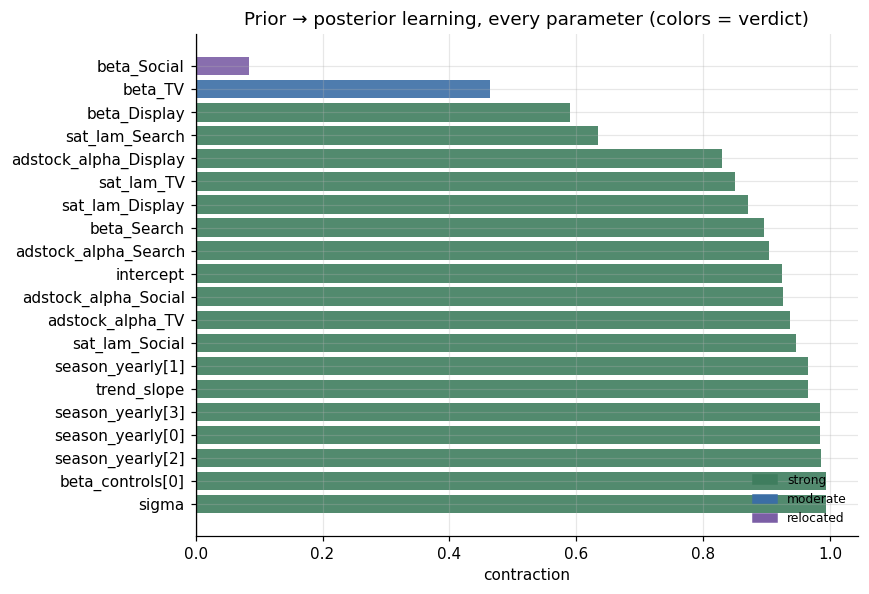

channel betas only:


,contraction,overlap,verdict
parameter,,,
beta_Social,0.084,0.362,relocated
beta_TV,0.464,0.388,moderate
beta_Display,0.589,0.672,strong
beta_Search,0.895,0.417,strong


✓ learning varies by parameter: structure pinned hard, some betas barely moved


In [11]:
with quiet():
    learn = mmm.compute_parameter_learning(prior_samples=1000, random_seed=0)
cols = ["parameter", "prior_sd", "post_sd", "contraction", "overlap", "shift_z", "verdict"]
display(learn[cols].round(3))

from mmm_framework.diagnostics import plot_parameter_learning
fig, ax = plt.subplots(figsize=(8, 5.5))
plot_parameter_learning(learn, ax=ax)
ax.set_title("Prior → posterior learning, every parameter (colors = verdict)")
plt.tight_layout(); plt.show()

betas_l = learn[learn["parameter"].isin(beta_names)].set_index("parameter")
print("channel betas only:")
display(betas_l[["contraction", "overlap", "verdict"]].round(3))

# CLAIM 1: the table is sorted least-learned first and verdicts are well-formed.
assert learn["contraction"].dropna().is_monotonic_increasing
assert set(learn["verdict"]) <= {"strong", "moderate", "weak", "relocated",
                                 "prior-dominated", "undetermined"}
# CLAIM 2: structural parameters the data sees every week (noise level, trend,
# intercept) are learned hard...
struct = learn.set_index("parameter")
assert struct.loc["sigma", "contraction"] > 0.5
assert struct.loc["trend_slope", "contraction"] > 0.5
assert struct.loc["intercept", "contraction"] > 0.5
# ...while the channel betas span verdicts — even in a fit whose attribution
# is good, individual betas can stay barely-updated (section 5 says why: the
# data constrains the contribution, and beta shares credit with the curve).
assert betas_l["verdict"].nunique() >= 2, betas_l["verdict"]
assert betas_l["contraction"].min() < 0.5 < struct.loc["sigma", "contraction"]
print("✓ learning varies by parameter: structure pinned hard, some betas barely moved")

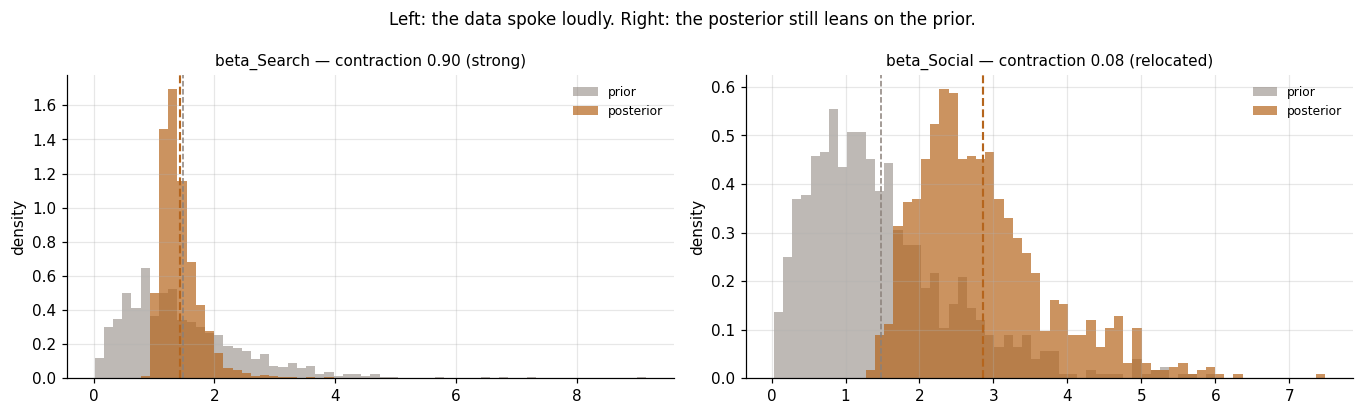

✓ post_sd/prior_sd: beta_Search 0.32 vs beta_Social 0.96


In [12]:
# SEE it for two betas: the most- and least-contracted, prior vs posterior.
from mmm_framework.diagnostics import plot_prior_posterior_overlay
with quiet():
    prior_idata = mmm.sample_prior_predictive(samples=1000)

b_most = betas_l["contraction"].idxmax()
b_least = betas_l["contraction"].idxmin()
fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.8))
for ax, p in zip(axes, (b_most, b_least)):
    plot_prior_posterior_overlay(prior_idata, mmm._trace, p, ax=ax)
    row = betas_l.loc[p]
    ax.set_title(f"{p} — contraction {row['contraction']:.2f} ({row['verdict']})",
                 fontsize=10)
fig.suptitle("Left: the data spoke loudly. Right: the posterior still leans on the prior.",
             fontsize=11)
plt.tight_layout(); plt.show()

# CLAIM: the most-contracted beta's posterior is much narrower than its prior;
# the least-contracted one's barely narrowed (ratio close to 1).
sd_ratio = lambda p: betas_l.loc[p, "post_sd"] / betas_l.loc[p, "prior_sd"]
assert sd_ratio(b_most) < 0.6, sd_ratio(b_most)
assert sd_ratio(b_least) > 0.75, sd_ratio(b_least)
print(f"✓ post_sd/prior_sd: {b_most} {sd_ratio(b_most):.2f} vs {b_least} {sd_ratio(b_least):.2f}")

Three habits to take from this section:

1. **Run it after every fit.** It costs seconds, and a `prior-dominated`
   verdict on a headline parameter changes what you're allowed to claim: the
   number is an assumption restated, so either gather data that speaks to it
   (workshop_05 touches lift tests) or report it explicitly as prior-driven.
2. **Contraction measures informativeness, not importance.** Look at the
   tables above: betas with weak learning can still belong to big, well-pinned
   contributions (section 5's trade-off is exactly why). Never rank channels
   by "which beta learned most".
3. **Negative contraction is a smoke alarm** — posterior wider than prior
   means the prior and data are fighting. None here, but when you see it, go
   back to workshop_01 and rethink that prior.

## 7 — The posterior predictive check: can the model fake your data?

So far we've read parameters. The **posterior predictive** flips the
direction: take each world in the table, *simulate the KPI it implies* (noise
and all), and stack the simulations. If the model is adequate, your observed
sales should look like just another simulation — nothing about it should
surprise the model.

`mmm.predict()` does this in one call, returning the per-draw simulated KPI
paths plus their mean and HDI band.

In [13]:
with quiet():
    pred = mmm.predict(return_original_scale=True, hdi_prob=0.90, random_seed=0)
print("simulated KPI paths:", pred.y_pred_samples.shape, "(draws × weeks)")

y_obs = sc.y.to_numpy(float)
cover = float(((y_obs >= pred.y_pred_hdi_low) & (y_obs <= pred.y_pred_hdi_high)).mean())
r2 = 1 - np.var(y_obs - pred.y_pred_mean) / np.var(y_obs)

figc = go.Figure()
figc.add_scatter(x=sc.weeks, y=pred.y_pred_hdi_high, mode="lines",
                 line=dict(width=0), showlegend=False, hoverinfo="skip")
figc.add_scatter(x=sc.weeks, y=pred.y_pred_hdi_low, mode="lines",
                 line=dict(width=0), fill="tonexty",
                 fillcolor="rgba(59,110,165,0.25)", name="90% predictive band")
rng = np.random.default_rng(0)
for j, k in enumerate(rng.choice(pred.y_pred_samples.shape[0], size=6, replace=False)):
    figc.add_scatter(x=sc.weeks, y=pred.y_pred_samples[k], mode="lines",
                     line=dict(color=SKY, width=0.7), opacity=0.45,
                     name="simulated worlds (6 shown)", legendgroup="spaghetti",
                     showlegend=(j == 0), hoverinfo="skip")
figc.add_scatter(x=sc.weeks, y=pred.y_pred_mean, mode="lines",
                 line=dict(color=SKY, width=2.2), name="posterior-predictive mean")
figc.add_scatter(x=sc.weeks, y=y_obs, mode="markers",
                 marker=dict(color=INK, size=4), name="observed sales",
                 hovertemplate="%{x|%Y-%m-%d}<br>sales %{y:.0f}<extra></extra>")
figc.update_layout(
    title=f"Posterior predictive check — band covers {cover:.0%} of weeks (target ≈ 90%), R² {r2:.2f}",
    xaxis_title="week", yaxis_title="weekly sales (KPI units)",
    width=900, height=420, template="plotly_white", legend=dict(x=0.01, y=0.99))
figc.show()

# CLAIM 1: the model reproduces the data it was fit to (this is the PASS look):
# high R², and the 90% band covers roughly 90% of observed weeks — neither
# drastically less (model too sure) nor ~100% with a huge band (model too vague).
assert r2 > 0.75, r2
assert 0.80 <= cover <= 0.99, cover
# CLAIM 2: the spaghetti draws look like data — same scale and spread as the
# observations, because each simulated world includes the noise term.
sim_sd = pred.y_pred_samples.std(axis=1).mean()
assert 0.5 * y_obs.std() < sim_sd < 2.0 * y_obs.std()
print("✓ PASS: observed sales are indistinguishable from the model's own simulations")

Output()

simulated KPI paths: (1000, 156) (draws × weeks)


✓ PASS: observed sales are indistinguishable from the model's own simulations


**What a pass looks like** (above): the dots thread through the band, the band
covers about as many weeks as it promises, and the **spaghetti** draws — thin
lines, each one simulated from a single posterior world — are honestly
data-shaped, not suspiciously smooth. The check has teeth in both directions:
a band that misses 30% of weeks means the model is *overconfident*; a band
that swallows everything with huge margins means it has learned almost
nothing.

**What failures look like:** observed dots drifting outside the band in runs
(a missing trend or seasonality), the band systematically too narrow in
high-sales seasons (wrong noise model), or whole stretches the simulations
never reach (a structural break). The stress series shows these live —
[stress_00](stress_00_the_rosy_picture.ipynb) and friends.

And one warning to carry forever: **this check validates fit, not causality.**
A model crediting the wrong channel can still fake your KPI perfectly
(stress_00 demonstrates exactly that). Passing PPC is necessary, never
sufficient.

## 8 — Decomposition with uncertainty: where the sales came from

The business question behind every MMM: *of the sales we observed, what part
did each thing cause?* The **decomposition** answers it by splitting the
model's predicted KPI into additive layers — baseline (intercept), trend,
seasonality, controls, and each media channel.

`mmm.compute_component_decomposition()` returns the posterior-*mean* path of
every component. Means first for the overview — then we'll put the
uncertainty back on, where this notebook's lesson lives.

In [14]:
dec = mmm.compute_component_decomposition()
parts = {"baseline (intercept)": dec.intercept, "trend": dec.trend,
         "seasonality": dec.seasonality, "controls": dec.controls_total}
for c in sc.channels:
    parts[f"media: {c}"] = dec.media_by_channel[c].to_numpy(float)
order = list(parts)
stack = np.vstack([parts[k] for k in order])
cum = np.cumsum(stack, axis=0)
base_cols = {"baseline (intercept)": "#d8d2c9", "trend": "#b8b0a4",
             "seasonality": "#979083", "controls": "#7b756b"}
cols = {**base_cols, **{f"media: {c}": PAL[c] for c in sc.channels}}

figd = go.Figure()
for i, k in enumerate(order):
    figd.add_scatter(x=sc.weeks, y=cum[i], mode="lines", name=k,
                     line=dict(color=cols[k], width=0.6),
                     fill="tonexty" if i else "tozeroy",
                     hovertemplate=k + ": %{customdata:.0f}<extra></extra>",
                     customdata=stack[i])
figd.add_scatter(x=sc.weeks, y=y_obs, mode="markers",
                 marker=dict(color=INK, size=3.5), name="observed sales")
figd.update_layout(
    title="Component decomposition (posterior MEANS): the KPI, explained layer by layer",
    xaxis_title="week", yaxis_title="weekly sales (KPI units)",
    width=900, height=460, template="plotly_white",
    legend=dict(font=dict(size=10)))
figd.show()

# CLAIM 1: the layers ADD UP to the model's prediction (same posterior, same scale).
recon = stack.sum(axis=0)
add_corr = float(np.corrcoef(recon, pred.y_pred_mean)[0, 1])
assert add_corr > 0.999, add_corr
# CLAIM 2: the decomposition's media totals match the channel_contributions
# posterior we used in section 5 — one consistent accounting throughout.
for i, c in enumerate(sc.channels):
    a = float(dec.media_by_channel[c].sum())
    bb = float(totals[:, i].mean())
    assert abs(a - bb) / abs(bb) < 0.05, (c, a, bb)
print(f"✓ layers sum to the prediction (corr {add_corr:.4f}); media layers agree "
      "with the per-draw contributions")

✓ layers sum to the prediction (corr 0.9999); media layers agree with the per-draw contributions


The stacked picture is what stakeholders ask for — and it's the most dangerous
chart in MMM, because **it shows means with no widths**. Each colored layer is
the *average* across 1,000 worlds that genuinely disagree.

So put the uncertainty back. For each channel we take its weekly contribution
in *every* posterior world (the `channel_contributions` posterior from section
5), and draw the 90% band around the mean path. And because this world is
synthetic, we can overlay the **true** weekly contribution path — the answer
key a real analyst never gets to see.

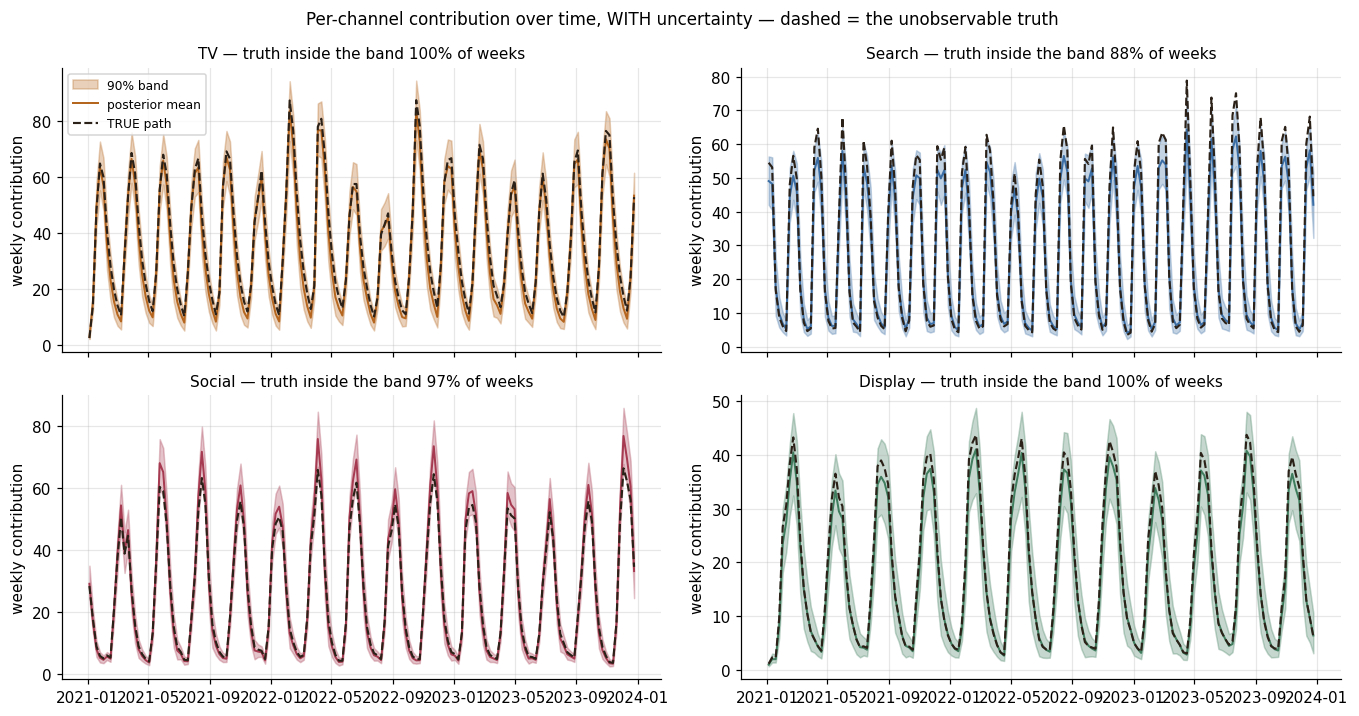

TV         100%
Search      88%
Social      97%
Display    100%
✓ honest bands: the truth lives inside them — the uncertainty was real information, not decoration


In [15]:
def true_path(c):
    "The DGP's true weekly contribution of channel c (KPI units)."
    xn = sc.spend[c].to_numpy(float) / float(sc.spend[c].max())
    return dgp._AMP[c] * dgp._logistic_sat(dgp._geom_adstock(xn, dgp._ALPHA[c]),
                                           dgp._LAM[c])

# Sanity: the weekly truth path integrates to the scenario's recorded totals.
for c in sc.channels:
    assert abs(true_path(c).sum() - sc.true_contribution[c]) < 1e-6

fig, axes = plt.subplots(2, 2, figsize=(12.5, 6.6), sharex=True)
inside = {}
for ax, c in zip(axes.ravel(), sc.channels):
    i = sc.channels.index(c)
    lo, hi = np.percentile(draws_kpi[:, :, i], [5, 95], axis=0)
    mean_path = draws_kpi[:, :, i].mean(axis=0)
    tp = true_path(c)
    inside[c] = float(((tp >= lo) & (tp <= hi)).mean())
    ax.fill_between(sc.weeks, lo, hi, color=PAL[c], alpha=0.30, label="90% band")
    ax.plot(sc.weeks, mean_path, color=PAL[c], lw=1.3, label="posterior mean")
    ax.plot(sc.weeks, tp, color=INK, lw=1.4, ls="--", label="TRUE path")
    ax.set_title(f"{c} — truth inside the band {inside[c]:.0%} of weeks", fontsize=10)
    ax.set_ylabel("weekly contribution")
axes[0, 0].legend(fontsize=8)
fig.suptitle("Per-channel contribution over time, WITH uncertainty — dashed = the "
             "unobservable truth", fontsize=11)
plt.tight_layout(); plt.show()
print(pd.Series(inside, name="truth inside 90% band").map("{:.0%}".format).to_string())

# CLAIM: on this clean world the bands are honest — for every channel the true
# weekly path lives inside the 90% band for the large majority of weeks.
assert all(v >= 0.7 for v in inside.values()), inside
print("✓ honest bands: the truth lives inside them — the uncertainty was real "
      "information, not decoration")

In [16]:
# 🎛️ Live exploration (run me!) — pick a channel: its beta marginal (scaled
# units) next to its weekly contribution band (KPI units) with the truth path.
from ipywidgets import interact, Dropdown

def channel_view(channel="TV"):
    i = sc.channels.index(channel)
    bb = post[f"beta_{channel}"].values.ravel()
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 3.6),
                                   gridspec_kw={"width_ratios": [1, 2]})
    kk = gaussian_kde(bb)
    xx = np.linspace(bb.min(), bb.max(), 300)
    ax1.fill_between(xx, kk(xx), color=PAL[channel], alpha=0.4)
    ax1.plot(xx, kk(xx), color=PAL[channel], lw=1.8)
    h90 = az.hdi(bb, hdi_prob=0.90)
    ax1.axvspan(h90[0], h90[1], color=PAL[channel], alpha=0.15)
    ax1.set_title(f"beta_{channel} marginal (90% HDI shaded)", fontsize=10)
    ax1.set_xlabel("beta (scaled units)")
    lo, hi = np.percentile(draws_kpi[:, :, i], [5, 95], axis=0)
    ax2.fill_between(sc.weeks, lo, hi, color=PAL[channel], alpha=0.30,
                     label="90% band")
    ax2.plot(sc.weeks, draws_kpi[:, :, i].mean(axis=0), color=PAL[channel],
             lw=1.3, label="posterior mean")
    ax2.plot(sc.weeks, true_path(channel), color=INK, lw=1.4, ls="--",
             label="TRUE path")
    ax2.set_title(f"{channel} weekly contribution (KPI units)", fontsize=10)
    ax2.legend(fontsize=8)
    plt.tight_layout(); plt.show()

interact(channel_view, channel=Dropdown(options=sc.channels, value="TV",
                                        description="channel"))

# CLAIM: the view is well-defined for every channel (data present and finite).
for c in sc.channels:
    assert np.isfinite(post[f"beta_{c}"].values).all()
    assert np.isfinite(true_path(c)).all()
print("✓ explore all four channels — note how different the marginal's width and "
      "the band's width can feel (section 5 explains why)")

interactive(children=(Dropdown(description='channel', options=('TV', 'Search', 'Social', 'Display'), value='TV…

✓ explore all four channels — note how different the marginal's width and the band's width can feel (section 5 explains why)


## 9 — Glossary, and where this goes next

| term | plain English |
|---|---|
| **draw / sample** | one row of the posterior table: a complete, self-consistent setting of every parameter — one plausible world |
| **marginal** | the distribution of a single parameter, ignoring all the others (one column of the table) |
| **joint** | the distribution of parameters *together* — including the correlations that make mix-and-match illegal |
| **HDI** | highest-density interval: the *narrowest* range holding the requested probability; everything inside is more plausible than everything outside |
| **equal-tailed interval** | percentile-based interval (e.g. 5th–95th); matches the HDI when symmetric, drifts into the tail when skewed |
| **credible interval** | any interval you can read literally: "90% chance the value is in here, given model + data" |
| **forest plot** | one line per parameter (dot = center, line = interval): the posterior at a glance, overclaiming made visible |
| **contraction** | 1 − posterior variance / prior variance: how much the data narrowed a parameter beyond the prior |
| **prior-dominated** | posterior ≈ prior: the data didn't speak — the number is your assumption wearing a lab coat |
| **posterior predictive** | data simulated from the posterior worlds, noise included; a model should be able to fake your dataset |
| **spaghetti plot** | a few individual simulated paths drawn thin, so you see what single worlds look like, not just the band |
| **decomposition** | the predicted KPI split into additive layers: baseline, trend, seasonality, controls, each channel |

**The one-sentence takeaway:** the posterior is a table of complete worlds —
summarize columns honestly (HDI), compare with intervals attached (forest),
respect the correlations between columns (joint), check the table against the
prior (learning) and against the data (posterior predictive), and keep the
bands on every business chart (decomposition).

**Next — [workshop_05: From Draws to Decisions](workshop_05_from_draws_to_decisions.ipynb).**
Every number a stakeholder actually wants — ROAS, marginal ROAS, "what if we
moved \$100k from Display to Search?" — is a *derived quantity*. Section 5
showed the rule that makes them trustworthy: **compute per draw, summarize
last**. workshop_05 applies it: full ROAS distributions per channel,
probabilities of statements ("P(Search ROAS > 1) = ..."), and decisions that
carry their uncertainty with them.